In [ ]:
#step 1:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")

In [ ]:
# step 2:Load dataset directly from scikit-learn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nMissing Values Check:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nDescriptive Statistics:")
display(df.describe())
df.head()

Dataset Dimensions: 150 rows, 5 columns

Missing Values Check:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Data Types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


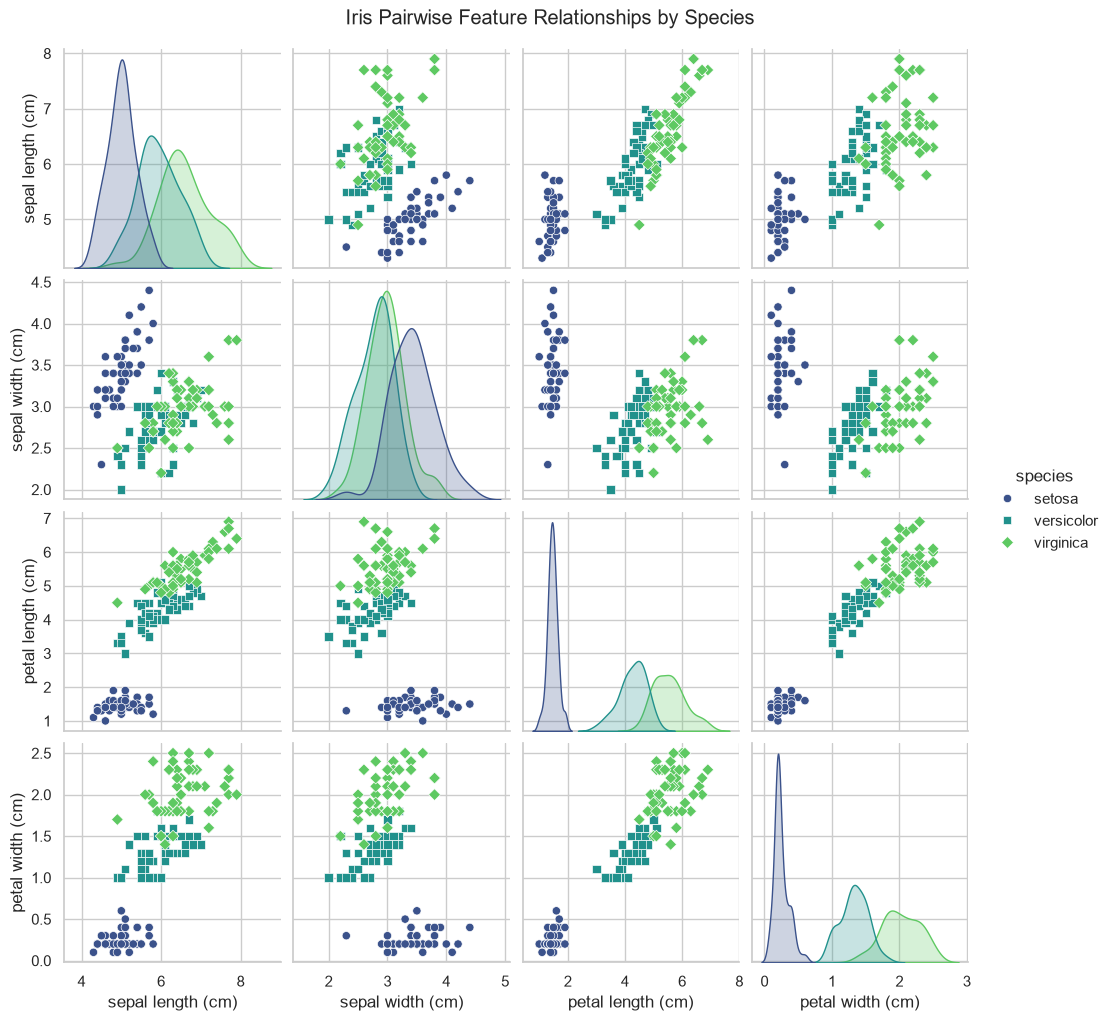

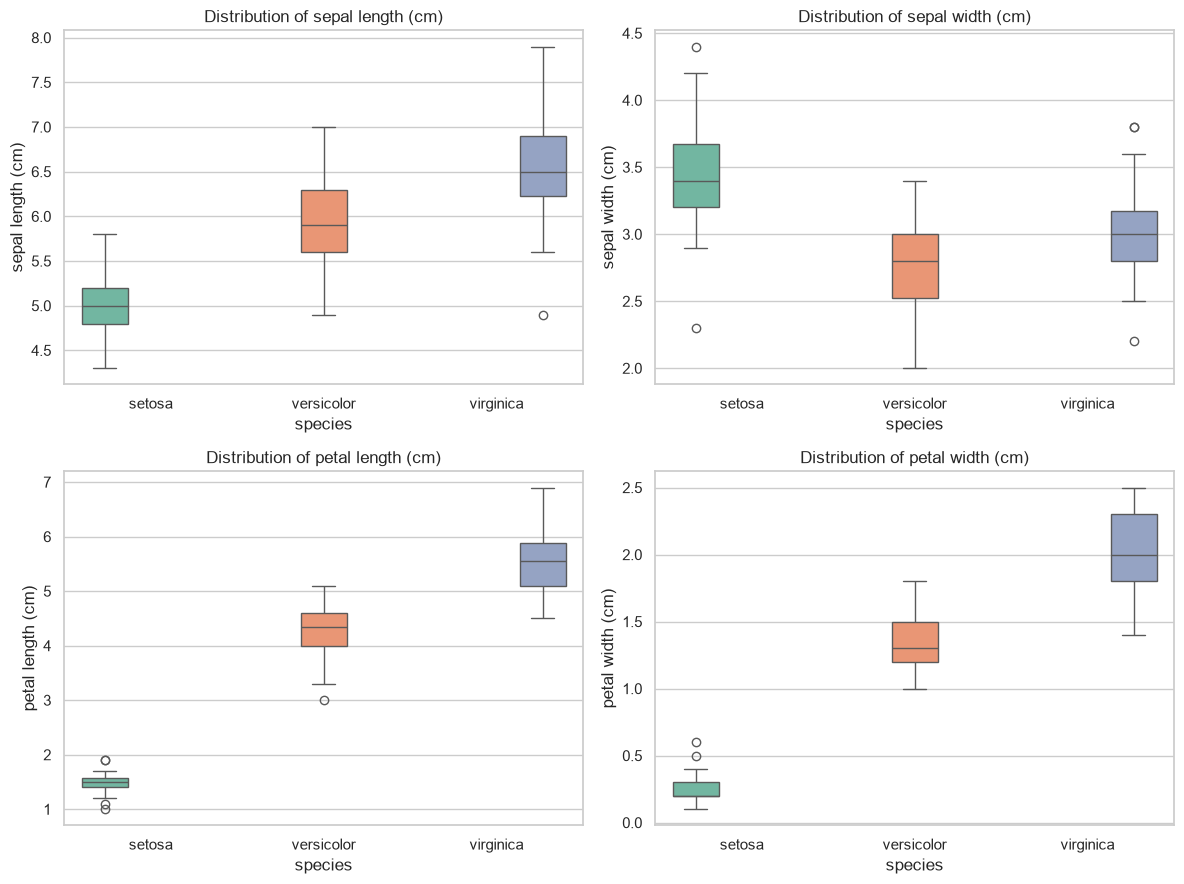

In [ ]:
#step 3
# 1. Pairplot across all features
sns.pairplot(df, hue="species", markers=["o", "s", "D"], palette="viridis")
plt.suptitle("Iris Pairwise Feature Relationships by Species", y=1.02)
plt.show()

# 2. Box plots for each measurement 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
features = iris.feature_names

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    sns.boxplot(
        x="species", 
        y=feature, 
        data=df, 
        hue="species", 
        legend=False, 
        ax=axes[row, col], 
        palette="Set2"
    )
    axes[row, col].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

Quantitative Feature Importance Rankings:
          Feature  Importance
petal length (cm)    0.436130
 petal width (cm)    0.436065
sepal length (cm)    0.106128
 sepal width (cm)    0.021678


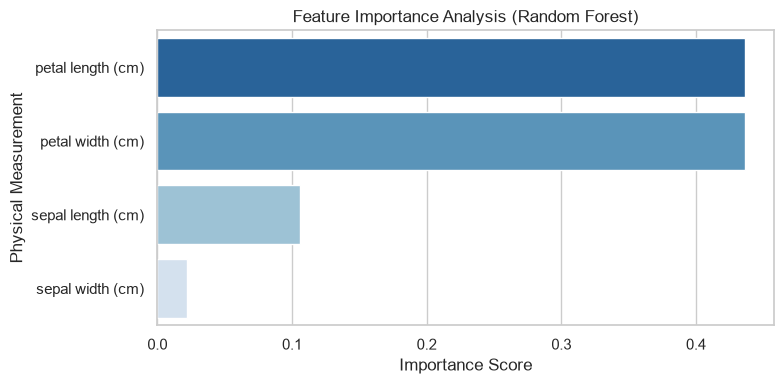

In [8]:
#step 4
from sklearn.ensemble import RandomForestClassifier

# Fit a baseline Random Forest to calculate feature importances
temp_rf = RandomForestClassifier(n_estimators=100, random_state=42)
temp_rf.fit(df.drop(columns=['species']), iris.target)

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': temp_rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Display ranked importances
print("Quantitative Feature Importance Rankings:")
print(feature_importance.to_string(index=False))

# Plot Feature Importance
plt.figure(figsize=(8, 4))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance, 
    hue='Feature', 
    legend=False, 
    palette='Blues_r'
)
plt.title("Feature Importance Analysis (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Physical Measurement")
plt.tight_layout()
plt.show()

In [10]:
#step 5
# 1. Train/Test Split (80/20 stratified)
X = df.drop(columns=['species'])
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Feature Scaling (essential for linear model convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# 4. Train Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(f"Dataset split: {len(X_train)} training samples, {len(X_test)} testing samples.")
print("Training complete: Both Logistic Regression and Random Forest fitted successfully.")

Dataset split: 120 training samples, 30 testing samples.
Training complete: Both Logistic Regression and Random Forest fitted successfully.


Logistic Regression Accuracy: 0.9333 (93.33%)
Random Forest Accuracy:       0.9000 (90.00%)

       LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

         RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



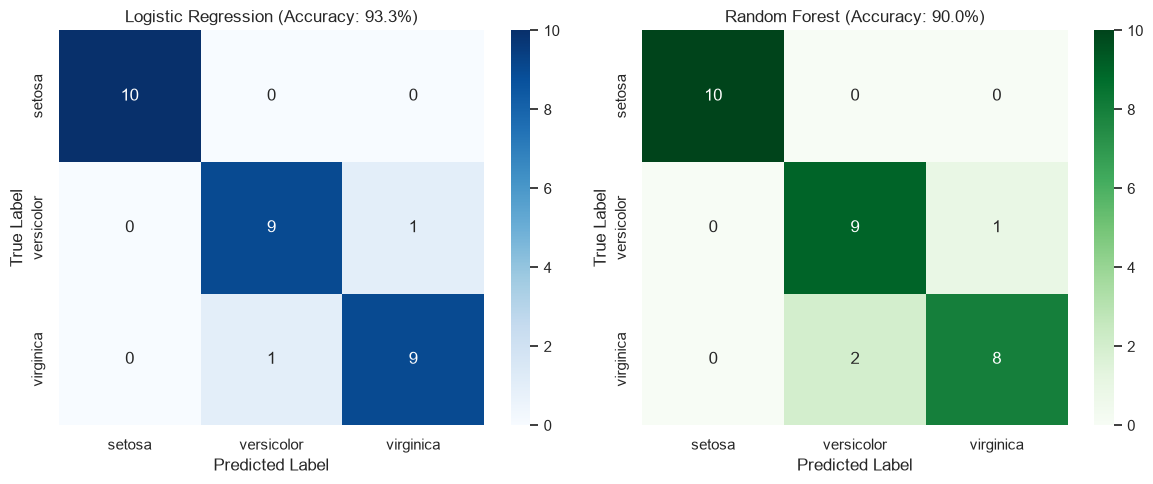

In [12]:
#step 6
# Calculate accuracy scores
lr_acc = accuracy_score(y_test, lr_preds)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"Random Forest Accuracy:       {rf_acc:.4f} ({rf_acc*100:.2f}%)")

# Detailed classification reports
print("\n" + "="*55)
print("       LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, lr_preds, target_names=iris.target_names))

print("="*55)
print("         RANDOM FOREST CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, rf_preds, target_names=iris.target_names))

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test, lr_preds), 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=iris.target_names, 
    yticklabels=iris.target_names, 
    ax=axes[0]
)
axes[0].set_title(f"Logistic Regression (Accuracy: {lr_acc*100:.1f}%)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    confusion_matrix(y_test, rf_preds), 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=iris.target_names, 
    yticklabels=iris.target_names, 
    ax=axes[1]
)
axes[1].set_title(f"Random Forest (Accuracy: {rf_acc*100:.1f}%)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [14]:
#step 7
# Quick inference test with new sample measurements
# Example: [sepal length, sepal width, petal length, petal width]
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=iris.feature_names)

# Scale using the fitted scaler
new_flower_scaled = scaler.transform(new_flower)

predicted_class = lr_model.predict(new_flower_scaled)[0]
probabilities = lr_model.predict_proba(new_flower_scaled)[0]

print(f"Predicted Species: {iris.target_names[predicted_class]}\n")
for idx, prob in enumerate(probabilities):
    print(f"Probability {iris.target_names[idx]}: {prob:.4f}")

Predicted Species: setosa

Probability setosa: 0.9808
Probability versicolor: 0.0192
Probability virginica: 0.0000
